In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

%cd /content
!git clone https://github.com/facebookresearch/sam2.git

%cd /content/sam2
!git checkout 2b90b9f5ceec907a1c18123530e92e794ad901a4
!pip install -q -e .
!pip install -q -U "transformers>=4.49,<5" accelerate safetensors

print("Commit SAM2:")
!git rev-parse HEAD

Tesla T4, 15360 MiB
/content
Cloning into 'sam2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 1107 (delta 10), reused 4 (delta 4), pack-reused 1093 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 27.55 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/content/sam2
Note: switching to '2b90b9f5ceec907a1c18123530e92e794ad901a4'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 2b90b9f remove `.

In [2]:
%cd /content/sam2

!mkdir -p checkpoints
!wget -q --show-progress \
  -O checkpoints/sam2.1_hiera_small.pt \
  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt

!ls -lh checkpoints/sam2.1_hiera_small.pt
!sha256sum checkpoints/sam2.1_hiera_small.pt

/content/sam2
checkpoints/sam2.1_ 100%[===================>] 175.87M   287MB/s    in 0.6s    
-rw-r--r-- 1 root root 176M Sep 29  2024 checkpoints/sam2.1_hiera_small.pt
6d1aa6f30de5c92224f8172114de081d104bbd23dd9dc5c58996f0cad5dc4d38  checkpoints/sam2.1_hiera_small.pt


In [3]:
%cd /content

from google.colab import files
uploaded = files.upload()

video_path = "/content/" + next(iter(uploaded))
print("Video caricato:", video_path)

/content


Saving san_donato_pilot_85_105.mp4 to san_donato_pilot_85_105.mp4
Video caricato: /content/san_donato_pilot_85_105.mp4


FPS: 24.999
Frame estratti: 500
Risoluzione: 640 x 512
Cartella: /content/san_donato_frames_e02


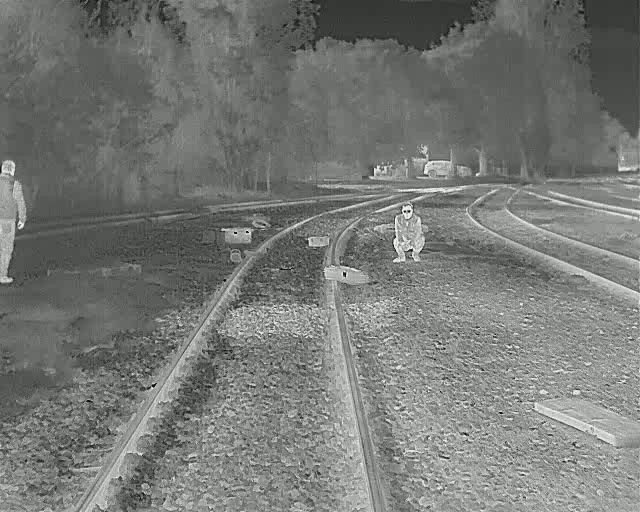

In [4]:
import cv2
import shutil
from pathlib import Path
from PIL import Image
from IPython.display import display

frames_dir = Path("/content/san_donato_frames_e02")

if frames_dir.exists():
    shutil.rmtree(frames_dir)
frames_dir.mkdir()

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

frame_count = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break

    cv2.imwrite(str(frames_dir / f"{frame_count:05d}.jpg"), frame)
    frame_count += 1

cap.release()

first_frame = Image.open(frames_dir / "00000.jpg").convert("RGB")

print("FPS:", fps)
print("Frame estratti:", frame_count)
print("Risoluzione:", width, "x", height)
print("Cartella:", frames_dir)
display(first_frame)

In [5]:
%cd /content/sam2

import torch
import transformers
from sam2.build_sam import build_sam2_video_predictor
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

SAM2_COMMIT = "2b90b9f5ceec907a1c18123530e92e794ad901a4"
SAM2_CHECKPOINT = "/content/sam2/checkpoints/sam2.1_hiera_small.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_s.yaml"
GDINO_MODEL_ID = "IDEA-Research/grounding-dino-tiny"

predictor = build_sam2_video_predictor(
    SAM2_CONFIG,
    SAM2_CHECKPOINT,
    device="cuda",
)

inference_state = predictor.init_state(
    video_path=str(frames_dir),
    offload_video_to_cpu=True,
)

gdino_processor = AutoProcessor.from_pretrained(GDINO_MODEL_ID)
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    GDINO_MODEL_ID
).to("cuda").eval()

print("SAM2 caricato")
print("Grounding DINO caricato:", GDINO_MODEL_ID)
print("Transformers:", transformers.__version__)
print("Frame disponibili:", len(inference_state["images"]))
print("GPU:", torch.cuda.get_device_name(0))

/content/sam2


frame loading (JPEG): 100%|██████████| 500/500 [00:20<00:00, 23.90it/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

SAM2 caricato
Grounding DINO caricato: IDEA-Research/grounding-dino-tiny
Transformers: 4.57.6
Frame disponibili: 500
GPU: Tesla T4


Rilevamenti ≥ 0.20: 3
Selezionati ≥ 0.30: 2
1 score: 0.771 box: [  0.  159.4  27.5 284.1]
2 score: 0.631 box: [391.8 201.8 425.2 262.7]
3 score: 0.224 box: [417.9 143.6 428.8 159.6]


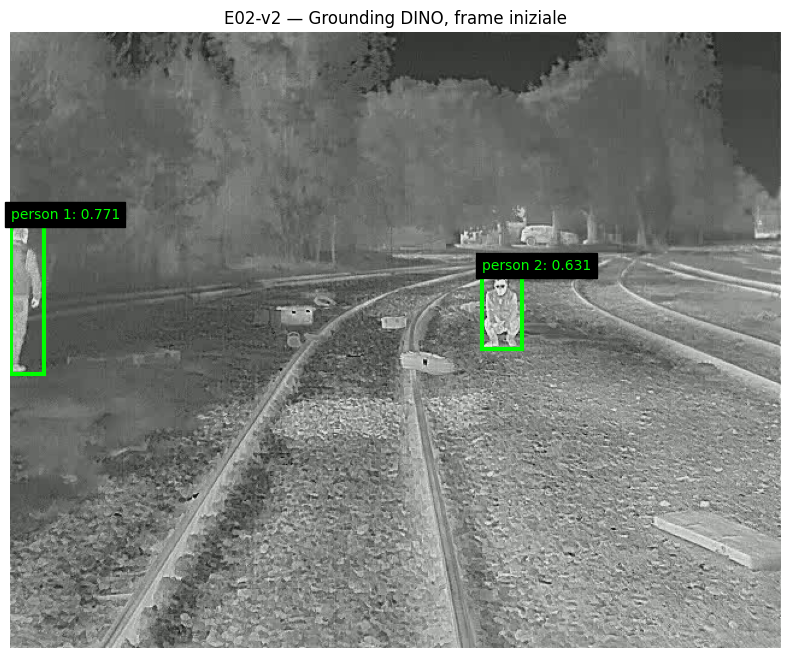

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

DETECTION_THRESHOLD = 0.20
TEXT_THRESHOLD = 0.15
SELECTION_THRESHOLD = 0.30
TEXT_LABELS = [["person"]]

gdino_inputs = gdino_processor(
    images=first_frame,
    text=TEXT_LABELS,
    return_tensors="pt",
).to("cuda")

with torch.inference_mode():
    gdino_outputs = gdino_model(**gdino_inputs)

result = gdino_processor.post_process_grounded_object_detection(
    gdino_outputs,
    gdino_inputs.input_ids,
    threshold=DETECTION_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
    target_sizes=[(first_frame.height, first_frame.width)],
)[0]

detected_boxes = result["boxes"].cpu().numpy()
detected_scores = result["scores"].cpu().numpy()

keep = detected_scores >= SELECTION_THRESHOLD
gdino_boxes_for_sam = detected_boxes[keep]
gdino_scores_for_sam = detected_scores[keep]

print("Rilevamenti ≥ 0.20:", len(detected_boxes))
print("Selezionati ≥ 0.30:", len(gdino_boxes_for_sam))

for index, (box, score) in enumerate(
    zip(detected_boxes, detected_scores), start=1
):
    print(index, "score:", round(float(score), 3), "box:", box.round(1))

plt.figure(figsize=(10, 8))
plt.imshow(first_frame)
axis = plt.gca()

for index, (box, score) in enumerate(
    zip(gdino_boxes_for_sam, gdino_scores_for_sam), start=1
):
    x1, y1, x2, y2 = box
    axis.add_patch(
        Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            edgecolor="lime",
            facecolor="none",
            linewidth=3,
        )
    )
    axis.text(
        x1,
        max(15, y1 - 5),
        f"person {index}: {score:.3f}",
        color="lime",
        backgroundcolor="black",
    )

plt.title("E02-v2 — Grounding DINO, frame iniziale")
plt.axis("off")
plt.savefig(
    "/content/E02_v2_gdino_frame0.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [7]:
from tqdm.auto import tqdm

predictor.reset_state(inference_state)

with torch.inference_mode():
    for object_id, box in enumerate(gdino_boxes_for_sam, start=1):
        predictor.add_new_points_or_box(
            inference_state=inference_state,
            frame_idx=0,
            obj_id=object_id,
            box=box.astype(np.float32),
        )

print("Oggetti inizializzati:", len(gdino_boxes_for_sam))

grounded_video_segments = {}

with torch.inference_mode(), torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
):
    for frame_idx, object_ids, mask_logits in tqdm(
        predictor.propagate_in_video(inference_state),
        total=frame_count,
    ):
        grounded_video_segments[int(frame_idx)] = {
            int(object_id): (
                mask_logits[index] > 0
            ).cpu().numpy().squeeze()
            for index, object_id in enumerate(object_ids)
        }

print("Frame elaborati:", len(grounded_video_segments))
print("Oggetti seguiti:", sorted(grounded_video_segments[0]))

Oggetti inizializzati: 2


/content/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


  0%|          | 0/500 [00:00<?, ?it/s]


propagate in video:  58%|█████▊    | 288/500 [01:11<01:26,  2.44it/s]/content/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(

propagate in video:  58%|█████▊    | 290/500 [03:47<1:56:02, 33.15s/it]/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)

propagate in video:  68

Frame elaborati: 500
Oggetti seguiti: [1, 2]


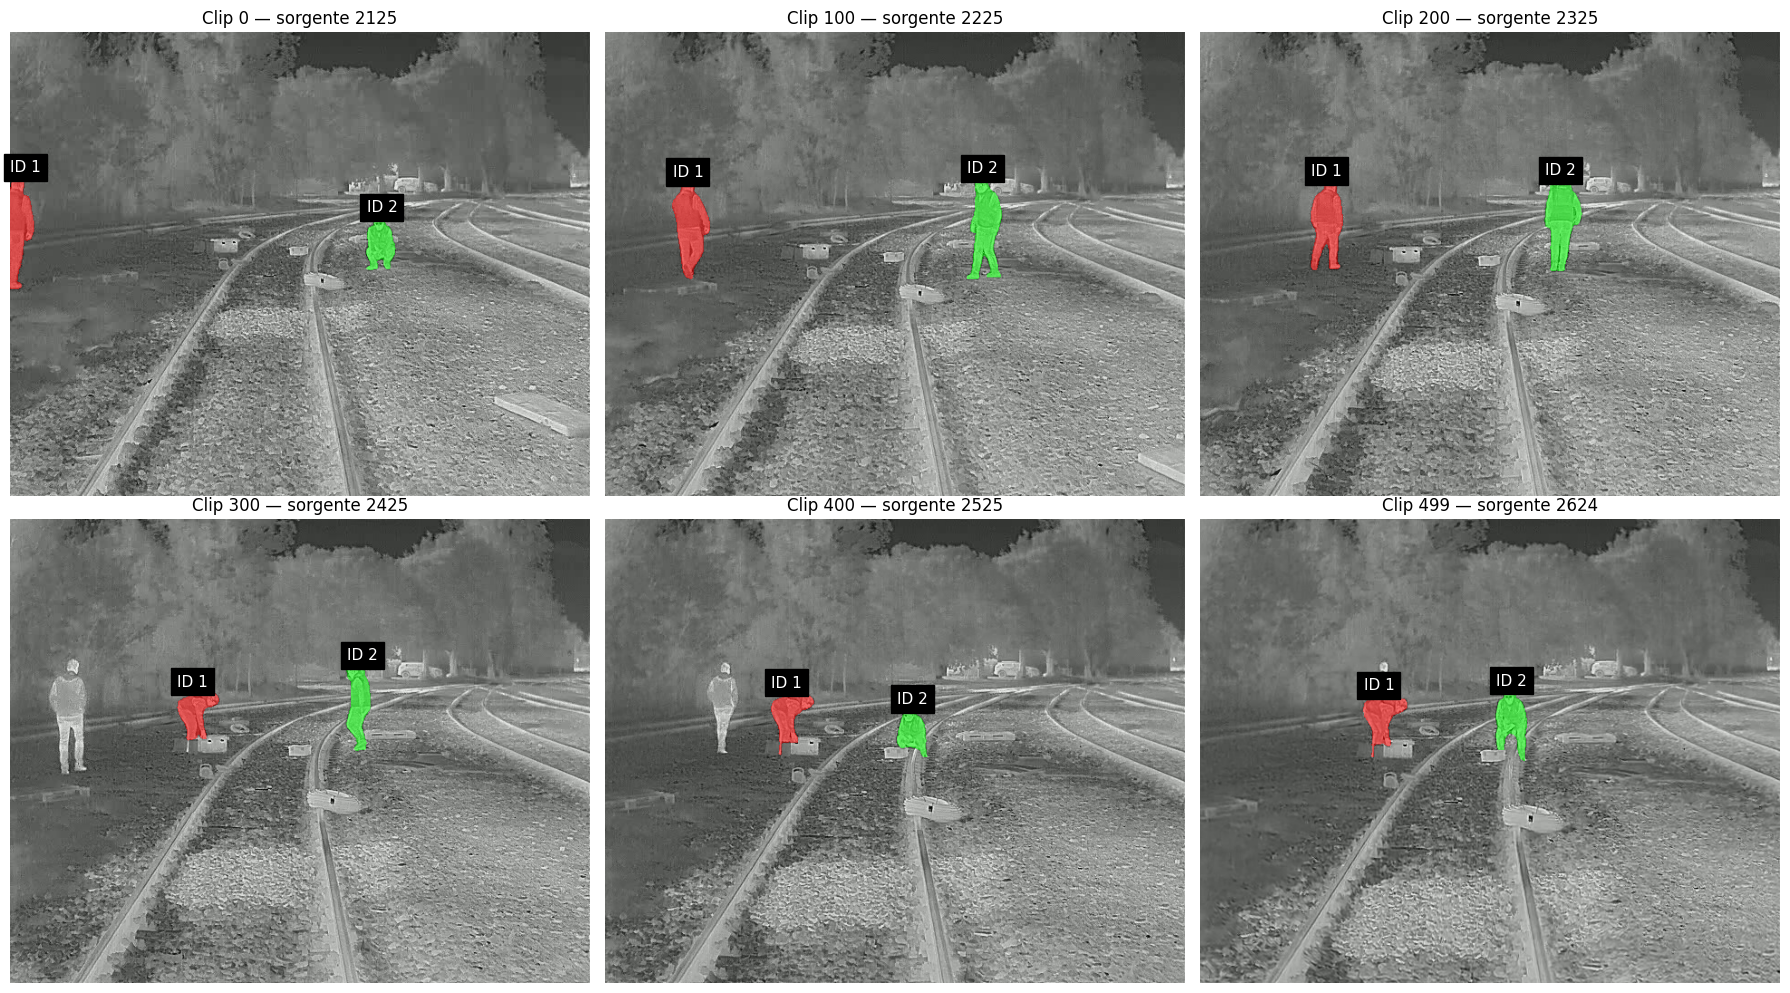

In [8]:
check_frames = [0, 100, 200, 300, 400, 499]

colors = {
    1: np.array([1.0, 0.0, 0.0, 0.55]),  # rosso
    2: np.array([0.0, 1.0, 0.0, 0.55]),  # verde
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, frame_idx in zip(axes.ravel(), check_frames):
    frame = np.array(
        Image.open(frames_dir / f"{frame_idx:05d}.jpg").convert("RGB")
    )
    axis.imshow(frame)

    for object_id, mask in grounded_video_segments[frame_idx].items():
        overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
        overlay[mask] = colors[object_id]
        axis.imshow(overlay)

        y, x = np.where(mask)
        if len(x):
            axis.text(
                x.min(),
                max(15, y.min() - 5),
                f"ID {object_id}",
                color="white",
                backgroundcolor="black",
                fontsize=11,
            )

    axis.set_title(
        f"Clip {frame_idx} — sorgente {2125 + frame_idx}"
    )
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/E02_v2_grounded_sam2_six_frames.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [9]:
def detect_people(frame_idx):
    image = Image.open(
        frames_dir / f"{frame_idx:05d}.jpg"
    ).convert("RGB")

    inputs = gdino_processor(
        images=image,
        text=[["person"]],
        return_tensors="pt",
    ).to("cuda")

    with torch.inference_mode():
        outputs = gdino_model(**inputs)

    result = gdino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=DETECTION_THRESHOLD,
        text_threshold=TEXT_THRESHOLD,
        target_sizes=[(image.height, image.width)],
    )[0]

    boxes = result["boxes"].cpu().numpy()
    scores = result["scores"].cpu().numpy()
    keep = scores >= SELECTION_THRESHOLD

    return boxes[keep], scores[keep]


periodic_frames = list(range(0, 500, 50))
periodic_detections = {}

for frame_idx in periodic_frames:
    boxes, scores = detect_people(frame_idx)
    periodic_detections[frame_idx] = {
        "boxes": boxes,
        "scores": scores,
    }

    print(
        f"Frame {frame_idx:3d} | "
        f"sorgente {2125 + frame_idx} | "
        f"persone selezionate: {len(boxes)} | "
        f"score: {[round(float(s), 3) for s in scores]}"
    )

Frame   0 | sorgente 2125 | persone selezionate: 2 | score: [0.771, 0.631]
Frame  50 | sorgente 2175 | persone selezionate: 2 | score: [0.769, 0.783]
Frame 100 | sorgente 2225 | persone selezionate: 2 | score: [0.763, 0.819]
Frame 150 | sorgente 2275 | persone selezionate: 2 | score: [0.758, 0.864]
Frame 200 | sorgente 2325 | persone selezionate: 2 | score: [0.768, 0.825]
Frame 250 | sorgente 2375 | persone selezionate: 3 | score: [0.787, 0.832, 0.526]
Frame 300 | sorgente 2425 | persone selezionate: 3 | score: [0.769, 0.789, 0.608]
Frame 350 | sorgente 2475 | persone selezionate: 4 | score: [0.79, 0.74, 0.387, 0.378]
Frame 400 | sorgente 2525 | persone selezionate: 3 | score: [0.799, 0.684, 0.58]
Frame 450 | sorgente 2575 | persone selezionate: 3 | score: [0.739, 0.522, 0.481]


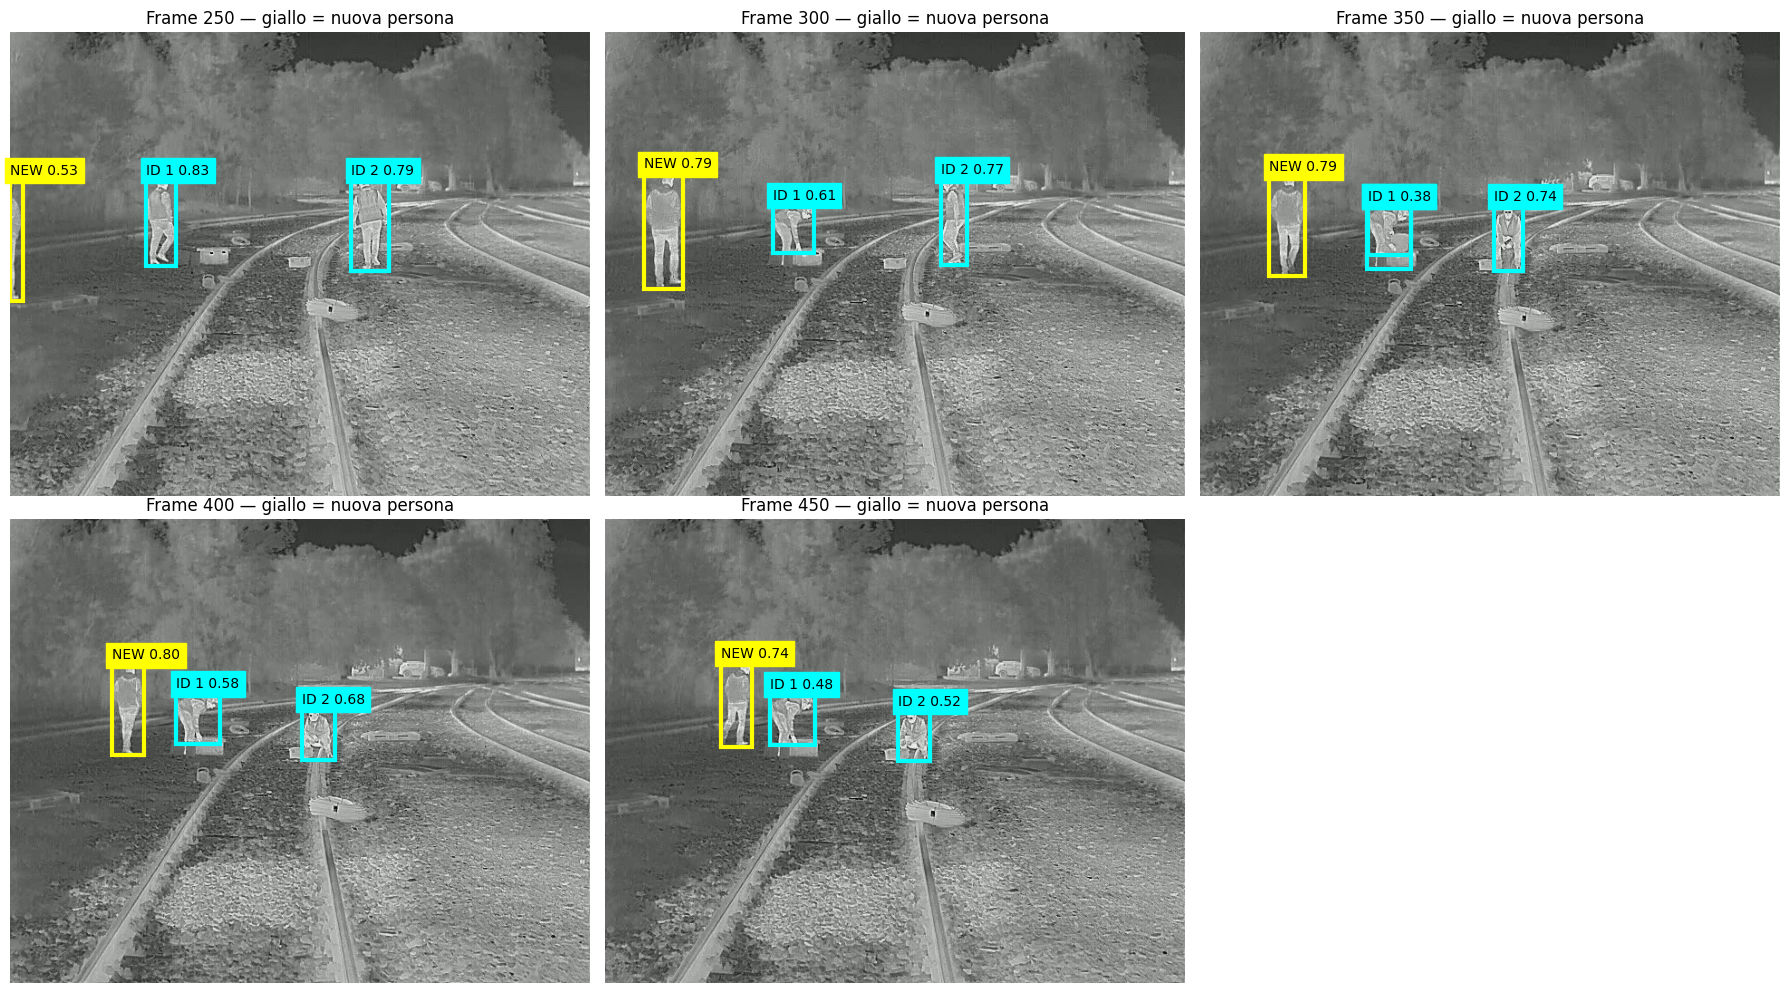

Candidati nuovi trovati: 5


In [10]:
def mask_to_box(mask):
    y, x = np.where(mask)
    if len(x) == 0:
        return None
    return np.array(
        [x.min(), y.min(), x.max() + 1, y.max() + 1],
        dtype=np.float32,
    )


def box_iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = max(0, box_a[2] - box_a[0]) * max(
        0, box_a[3] - box_a[1]
    )
    area_b = max(0, box_b[2] - box_b[0]) * max(
        0, box_b[3] - box_b[1]
    )

    return intersection / max(area_a + area_b - intersection, 1e-9)


MATCH_IOU_THRESHOLD = 0.20
inspection_frames = [250, 300, 350, 400, 450]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
new_candidate_rows = []

for axis, frame_idx in zip(axes.ravel(), inspection_frames):
    image = np.array(
        Image.open(frames_dir / f"{frame_idx:05d}.jpg").convert("RGB")
    )
    axis.imshow(image)

    existing_boxes = {
        object_id: mask_to_box(mask)
        for object_id, mask in grounded_video_segments[frame_idx].items()
    }

    boxes = periodic_detections[frame_idx]["boxes"]
    scores = periodic_detections[frame_idx]["scores"]

    for detection_id, (box, score) in enumerate(
        zip(boxes, scores), start=1
    ):
        ious = {
            object_id: box_iou(box, tracked_box)
            for object_id, tracked_box in existing_boxes.items()
            if tracked_box is not None
        }

        matched_id = max(ious, key=ious.get)
        best_iou = ious[matched_id]
        is_new = best_iou < MATCH_IOU_THRESHOLD

        color = "yellow" if is_new else "cyan"
        label = (
            f"NEW {score:.2f}"
            if is_new
            else f"ID {matched_id} {score:.2f}"
        )

        x1, y1, x2, y2 = box
        axis.add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                edgecolor=color,
                facecolor="none",
                linewidth=3,
            )
        )
        axis.text(
            x1,
            max(15, y1 - 4),
            label,
            color="black",
            backgroundcolor=color,
        )

        if is_new:
            new_candidate_rows.append(
                {
                    "clip_frame": frame_idx,
                    "source_frame": 2125 + frame_idx,
                    "score": float(score),
                    "xtl": float(x1),
                    "ytl": float(y1),
                    "xbr": float(x2),
                    "ybr": float(y2),
                    "best_existing_iou": float(best_iou),
                }
            )

    axis.set_title(f"Frame {frame_idx} — giallo = nuova persona")
    axis.axis("off")

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(
    "/content/E02_v2_periodic_new_candidates.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Candidati nuovi trovati:", len(new_candidate_rows))

In [11]:
earliest_frame = min(
    row["clip_frame"] for row in new_candidate_rows
)

earliest_candidates = [
    row for row in new_candidate_rows
    if row["clip_frame"] == earliest_frame
]

new_person_prompt = max(
    earliest_candidates,
    key=lambda row: row["score"],
)

new_box = np.array(
    [
        new_person_prompt["xtl"],
        new_person_prompt["ytl"],
        new_person_prompt["xbr"],
        new_person_prompt["ybr"],
    ],
    dtype=np.float32,
)

NEW_OBJECT_ID = 3

print("Nuova persona:")
print("Frame clip:", earliest_frame)
print("Frame sorgente:", 2125 + earliest_frame)
print("Score:", new_person_prompt["score"])
print("Box:", new_box)

with torch.inference_mode():
    _, prompt_object_ids, prompt_mask_logits = (
        predictor.add_new_points_or_box(
            inference_state=inference_state,
            frame_idx=earliest_frame,
            obj_id=NEW_OBJECT_ID,
            box=new_box,
        )
    )

periodic_video_segments = {
    frame_idx: dict(objects)
    for frame_idx, objects in grounded_video_segments.items()
}

with torch.inference_mode(), torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
):
    for frame_idx, object_ids, mask_logits in tqdm(
        predictor.propagate_in_video(
            inference_state,
            start_frame_idx=earliest_frame,
        ),
        total=frame_count - earliest_frame,
    ):
        periodic_video_segments[int(frame_idx)] = {
            int(object_id): (
                mask_logits[index] > 0
            ).cpu().numpy().squeeze()
            for index, object_id in enumerate(object_ids)
        }

print("ID prima del nuovo ingresso:",
      sorted(periodic_video_segments[249]))
print("ID al frame 250:",
      sorted(periodic_video_segments[250]))
print("ID al frame finale:",
      sorted(periodic_video_segments[499]))

Nuova persona:
Frame clip: 250
Frame sorgente: 2375
Score: 0.5256555676460266
Box: [2.5797486e-02 1.6085626e+02 1.3827610e+01 2.9633569e+02]


/content/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


  0%|          | 0/250 [00:00<?, ?it/s]


propagate in video: 100%|██████████| 250/250 [01:23<00:00,  3.00it/s]

ID prima del nuovo ingresso: [1, 2]
ID al frame 250: [1, 2, 3]
ID al frame finale: [1, 2, 3]


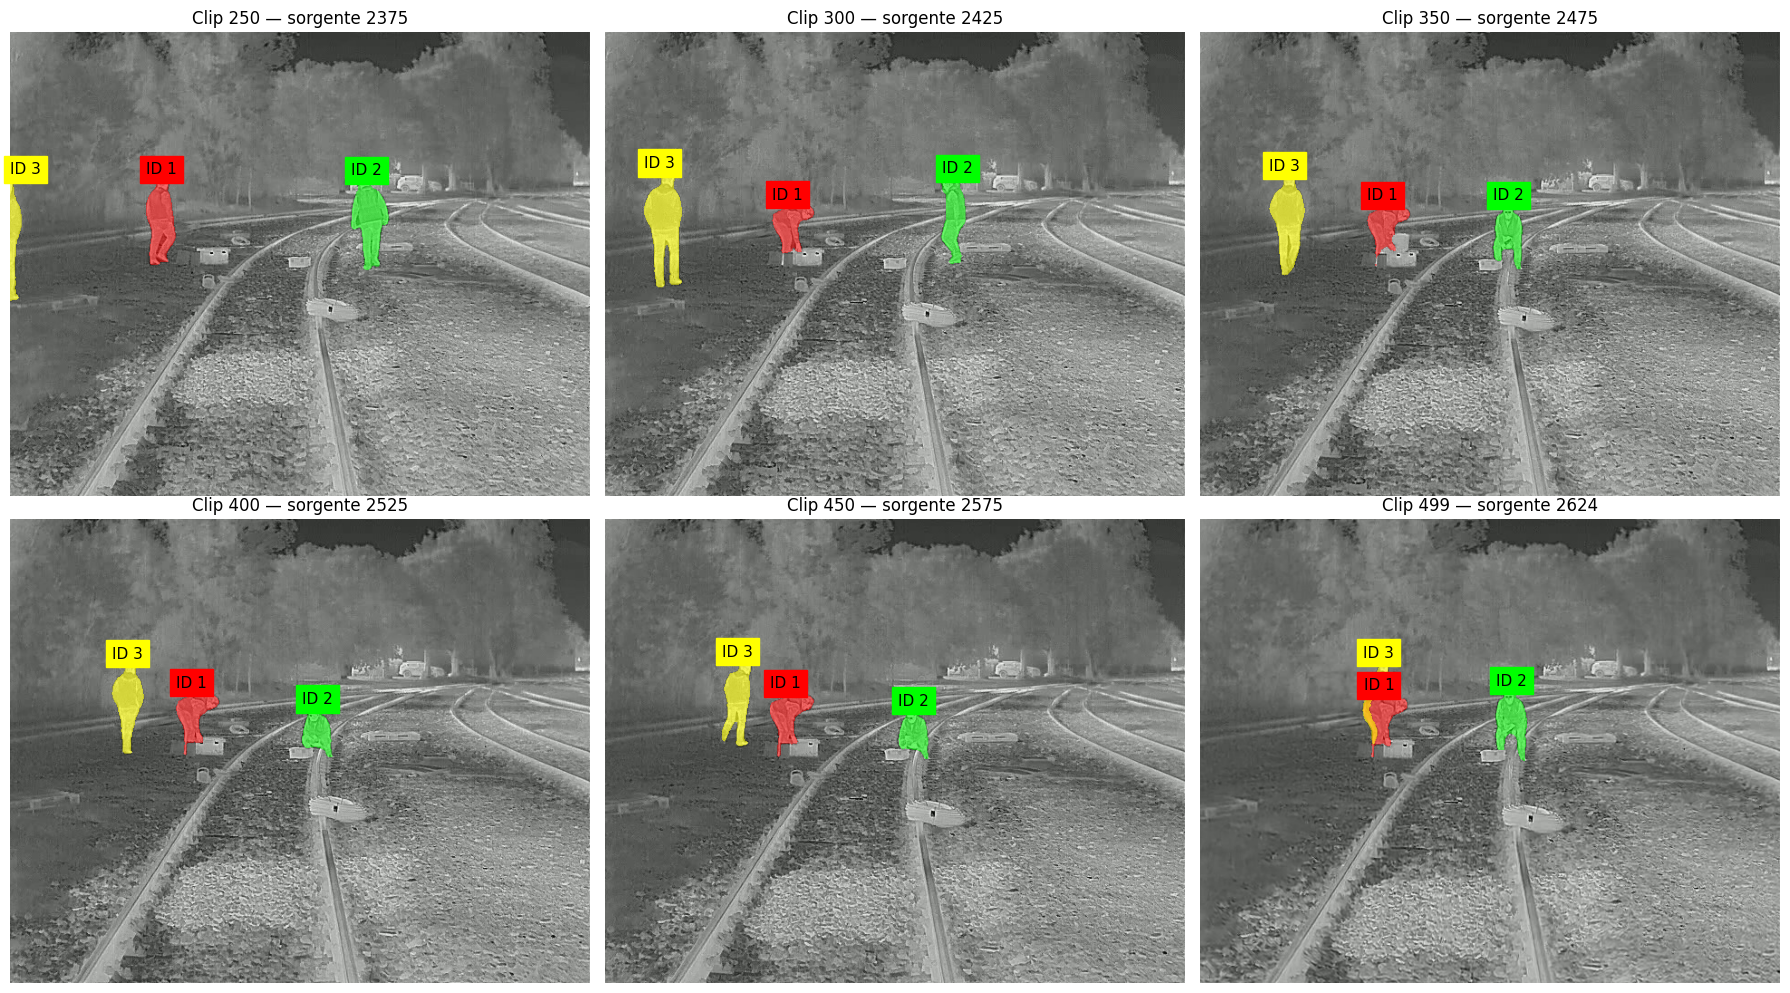

In [12]:
check_frames_periodic = [250, 300, 350, 400, 450, 499]

colors_periodic = {
    1: np.array([1.0, 0.0, 0.0, 0.55]),
    2: np.array([0.0, 1.0, 0.0, 0.55]),
    3: np.array([1.0, 1.0, 0.0, 0.60]),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, frame_idx in zip(axes.ravel(), check_frames_periodic):
    frame = np.array(
        Image.open(frames_dir / f"{frame_idx:05d}.jpg").convert("RGB")
    )
    axis.imshow(frame)

    for object_id, mask in periodic_video_segments[frame_idx].items():
        overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
        overlay[mask] = colors_periodic[object_id]
        axis.imshow(overlay)

        y, x = np.where(mask)
        if len(x):
            axis.text(
                x.min(),
                max(15, y.min() - 5),
                f"ID {object_id}",
                color="black",
                backgroundcolor=colors_periodic[object_id][:3],
                fontsize=11,
            )

    axis.set_title(
        f"Clip {frame_idx} — sorgente {2125 + frame_idx}"
    )
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/E02_v2_periodic_sam2_six_frames.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [13]:
%cd /content

uploaded_gt = files.upload()
gt_path = "/content/" + next(iter(uploaded_gt))

print("Ground truth caricata:", gt_path)

/content


Saving test_video_san_donato_v2_reviewed_boxes.csv to test_video_san_donato_v2_reviewed_boxes.csv
Ground truth caricata: /content/test_video_san_donato_v2_reviewed_boxes.csv


In [14]:
import pandas as pd

SOURCE_START_FRAME = 2125
TRACK_MAPPING = {
    1: 10,  # persona iniziale a sinistra
    2: 0,   # persona centrale
    3: 12,  # persona entrata successivamente
}

# Converte le maschere SAM2 in box per ogni frame
prediction_rows = []

for clip_frame, objects in periodic_video_segments.items():
    for object_id, mask in objects.items():
        box = mask_to_box(mask)
        if box is None:
            continue

        prediction_rows.append({
            "clip_frame": clip_frame,
            "frame": SOURCE_START_FRAME + clip_frame,
            "object_id": object_id,
            "xtl": float(box[0]),
            "ytl": float(box[1]),
            "xbr": float(box[2]),
            "ybr": float(box[3]),
            "mask_area_pixels": int(mask.sum()),
        })

predictions_df = pd.DataFrame(prediction_rows)
gt_df = pd.read_csv(gt_path)

gt_people = gt_df[
    (gt_df["frame"].between(2125, 2624))
    & (gt_df["outside"] == 0)
    & (gt_df["tipo"] == "persona")
].copy()


def calculate_iou_table(table):
    x1 = np.maximum(table["xtl_pred"], table["xtl_gt"])
    y1 = np.maximum(table["ytl_pred"], table["ytl_gt"])
    x2 = np.minimum(table["xbr_pred"], table["xbr_gt"])
    y2 = np.minimum(table["ybr_pred"], table["ybr_gt"])

    intersection = (
        np.maximum(0, x2 - x1)
        * np.maximum(0, y2 - y1)
    )

    pred_area = (
        (table["xbr_pred"] - table["xtl_pred"])
        * (table["ybr_pred"] - table["ytl_pred"])
    )
    gt_area = (
        (table["xbr_gt"] - table["xtl_gt"])
        * (table["ybr_gt"] - table["ytl_gt"])
    )

    return intersection / np.maximum(
        pred_area + gt_area - intersection,
        1e-9,
    )


per_frame_tables = []
summary_rows = []
overview_rows = []

for object_id, gt_track_id in TRACK_MAPPING.items():
    pred_track = predictions_df[
        predictions_df["object_id"] == object_id
    ].copy()

    gt_track = gt_people[
        gt_people["track_id"] == gt_track_id
    ][["frame", "xtl", "ytl", "xbr", "ybr"]].copy()

    common = pred_track.merge(
        gt_track,
        on="frame",
        suffixes=("_pred", "_gt"),
    )
    common["iou"] = calculate_iou_table(common)
    common["gt_track_id"] = gt_track_id
    per_frame_tables.append(common)

    pred_frames = set(pred_track["frame"])
    gt_frames = set(gt_track["frame"])

    overview_rows.append({
        "pred_object_id": object_id,
        "gt_track_id": gt_track_id,
        "predicted_frames": len(pred_frames),
        "gt_frames": len(gt_frames),
        "common_frames": len(common),
        "extra_prediction_frames": len(pred_frames - gt_frames),
        "missed_gt_frames": len(gt_frames - pred_frames),
    })

    for threshold in [0.30, 0.50]:
        tp = int((common["iou"] >= threshold).sum())
        failures = len(common) - tp

        precision = tp / len(common)
        recall = tp / len(common)

        summary_rows.append({
            "scope": "matched_track_common_interval",
            "pred_object_id": object_id,
            "gt_track_id": gt_track_id,
            "frames": len(common),
            "iou_threshold": threshold,
            "tp": tp,
            "fp": failures,
            "fn": failures,
            "precision": precision,
            "recall": recall,
            "f1": precision,
            "mean_iou": common["iou"].mean(),
            "median_iou": common["iou"].median(),
            "min_iou": common["iou"].min(),
            "max_iou": common["iou"].max(),
        })

per_frame_iou = pd.concat(per_frame_tables, ignore_index=True)
summary = pd.DataFrame(summary_rows)
track_overview = pd.DataFrame(overview_rows)

predictions_df.to_csv(
    "/content/E02_v2_predictions_boxes.csv",
    index=False,
)
per_frame_iou.to_csv(
    "/content/E02_v2_per_frame_iou.csv",
    index=False,
)
summary.to_csv(
    "/content/E02_v2_summary.csv",
    index=False,
)
track_overview.to_csv(
    "/content/E02_v2_track_overview.csv",
    index=False,
)

print("Copertura delle track:")
display(track_overview)

print("Metriche:")
display(summary)

Copertura delle track:


,pred_object_id,gt_track_id,predicted_frames,gt_frames,common_frames,extra_prediction_frames,missed_gt_frames
0,1,10,500,500,500,0,0
1,2,0,500,490,490,10,0
2,3,12,250,242,242,8,0


Metriche:


,scope,pred_object_id,gt_track_id,frames,iou_threshold,tp,fp,fn,precision,recall,f1,mean_iou,median_iou,min_iou,max_iou
0,matched_track_common_interval,1,10,500,0.3,500,0,0,1.000000,1.000000,1.000000,0.675021,0.692857,0.356072,0.950188
1,matched_track_common_interval,1,10,500,0.5,444,56,56,0.888000,0.888000,0.888000,0.675021,0.692857,0.356072,0.950188
2,matched_track_common_interval,2,0,490,0.3,490,0,0,1.000000,1.000000,1.000000,0.750671,0.757980,0.560445,0.951008
3,matched_track_common_interval,2,0,490,0.5,490,0,0,1.000000,1.000000,1.000000,0.750671,0.757980,0.560445,0.951008
4,matched_track_common_interval,3,12,242,0.3,242,0,0,1.000000,1.000000,1.000000,0.683900,0.701501,0.434097,0.960847
5,matched_track_common_interval,3,12,242,0.5,232,10,10,0.958678,0.958678,0.958678,0.683900,0.701501,0.434097,0.960847


In [15]:
overlay_colors = {
    1: np.array([0, 0, 255], dtype=np.float32),
    2: np.array([0, 255, 0], dtype=np.float32),
    3: np.array([0, 255, 255], dtype=np.float32),
}

mp4v_path = "/content/E02_v2_overlay_mp4v.mp4"

writer = cv2.VideoWriter(
    mp4v_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

for frame_idx in range(frame_count):
    frame = cv2.imread(
        str(frames_dir / f"{frame_idx:05d}.jpg")
    )

    for object_id, mask in periodic_video_segments[frame_idx].items():
        mask = mask.astype(bool)
        color = overlay_colors[object_id]

        frame[mask] = (
            0.45 * frame[mask].astype(np.float32)
            + 0.55 * color
        ).astype(np.uint8)

        box = mask_to_box(mask)
        if box is not None:
            x1, y1, x2, y2 = box.astype(int)

            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                tuple(int(v) for v in color),
                2,
            )
            cv2.putText(
                frame,
                f"ID {object_id}",
                (x1, max(20, y1 - 7)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                tuple(int(v) for v in color),
                2,
                cv2.LINE_AA,
            )

    cv2.putText(
        frame,
        f"clip {frame_idx} | source {2125 + frame_idx}",
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    writer.write(frame)

writer.release()
print("Video MP4V creato:", mp4v_path)

Video MP4V creato: /content/E02_v2_overlay_mp4v.mp4


In [16]:
!ffmpeg -y -loglevel error \
  -i /content/E02_v2_overlay_mp4v.mp4 \
  -c:v libx264 -preset fast -crf 20 \
  -pix_fmt yuv420p -movflags +faststart \
  /content/E02_v2_overlay_h264.mp4

!ls -lh /content/E02_v2_overlay_h264.mp4

-rw-r--r-- 1 root root 7.1M Jul  4 20:43 /content/E02_v2_overlay_h264.mp4


In [17]:
import json
import zipfile
import hashlib
import os

# 1. Metriche aggregate
aggregate_rows = []

for threshold in [0.30, 0.50]:
    tp = int((per_frame_iou["iou"] >= threshold).sum())
    failures = len(per_frame_iou) - tp
    score = tp / len(per_frame_iou)

    aggregate_rows.append({
        "scope": "all_matched_tracks_common_intervals",
        "pred_object_id": "ALL",
        "gt_track_id": "0,10,12",
        "frames": len(per_frame_iou),
        "iou_threshold": threshold,
        "tp": tp,
        "fp": failures,
        "fn": failures,
        "precision": score,
        "recall": score,
        "f1": score,
        "mean_iou": per_frame_iou["iou"].mean(),
        "median_iou": per_frame_iou["iou"].median(),
        "min_iou": per_frame_iou["iou"].min(),
        "max_iou": per_frame_iou["iou"].max(),
    })

summary_extended = pd.concat(
    [summary, pd.DataFrame(aggregate_rows)],
    ignore_index=True,
)
summary_extended.to_csv(
    "/content/E02_v2_summary_with_aggregate.csv",
    index=False,
)

# 2. Detection periodiche
periodic_detection_rows = []

for frame_idx, detection_data in periodic_detections.items():
    for detection_id, (box, score) in enumerate(
        zip(detection_data["boxes"], detection_data["scores"]),
        start=1,
    ):
        periodic_detection_rows.append({
            "clip_frame": frame_idx,
            "source_frame": SOURCE_START_FRAME + frame_idx,
            "detection_id": detection_id,
            "prompt": "person",
            "score": float(score),
            "xtl": float(box[0]),
            "ytl": float(box[1]),
            "xbr": float(box[2]),
            "ybr": float(box[3]),
        })

pd.DataFrame(periodic_detection_rows).to_csv(
    "/content/E02_v2_periodic_detections.csv",
    index=False,
)
pd.DataFrame(new_candidate_rows).to_csv(
    "/content/E02_v2_new_candidate_matches.csv",
    index=False,
)

# 3. Prompt effettivamente passati a SAM2
prompt_rows = []

for object_id, (box, score) in enumerate(
    zip(gdino_boxes_for_sam, gdino_scores_for_sam),
    start=1,
):
    prompt_rows.append({
        "object_id": object_id,
        "clip_frame": 0,
        "source_frame": SOURCE_START_FRAME,
        "score": float(score),
        "xtl": float(box[0]),
        "ytl": float(box[1]),
        "xbr": float(box[2]),
        "ybr": float(box[3]),
    })

prompt_rows.append({
    "object_id": 3,
    "clip_frame": earliest_frame,
    "source_frame": SOURCE_START_FRAME + earliest_frame,
    "score": float(new_person_prompt["score"]),
    "xtl": float(new_box[0]),
    "ytl": float(new_box[1]),
    "xbr": float(new_box[2]),
    "ybr": float(new_box[3]),
})

pd.DataFrame(prompt_rows).to_csv(
    "/content/E02_v2_sam2_prompts.csv",
    index=False,
)

# 4. Ground truth delle sole track abbinate
matched_gt = gt_df[
    gt_df["track_id"].isin(TRACK_MAPPING.values())
    & gt_df["frame"].between(2125, 2624)
].copy()

matched_gt.to_csv(
    "/content/E02_v2_matched_ground_truth.csv",
    index=False,
)

# 5. Maschere compresse con packbits
object_ids_array = np.array([1, 2, 3], dtype=np.int32)
packed_width = (width + 7) // 8

packed_masks = np.zeros(
    (frame_count, 3, height, packed_width),
    dtype=np.uint8,
)

for frame_idx in range(frame_count):
    for object_position, object_id in enumerate(object_ids_array):
        mask = periodic_video_segments[frame_idx].get(int(object_id))
        if mask is not None:
            packed_masks[frame_idx, object_position] = np.packbits(
                mask.astype(np.uint8),
                axis=-1,
                bitorder="little",
            )

np.savez_compressed(
    "/content/E02_v2_masks_packbits.npz",
    masks_packbits=packed_masks,
    object_ids=object_ids_array,
    source_frames=np.arange(2125, 2625),
    original_height=np.array(height),
    original_width=np.array(width),
    bitorder=np.array("little"),
)

# 6. Metadati riproducibili
metadata = {
    "experiment_id": "E02_v2_grounding_dino_periodic_sam2",
    "date": "2026-07-04",
    "source_video": "test_video_san_donato.mp4",
    "clip_seconds": [85, 105],
    "source_frames": [2125, 2624],
    "frame_count": frame_count,
    "fps": float(fps),
    "resolution": [width, height],
    "hardware": torch.cuda.get_device_name(0),
    "fine_tuning": False,
    "grounding_dino": {
        "model": GDINO_MODEL_ID,
        "prompt": "person",
        "detection_threshold": DETECTION_THRESHOLD,
        "text_threshold": TEXT_THRESHOLD,
        "selection_threshold": SELECTION_THRESHOLD,
        "period_frames": 50,
        "nms": None,
    },
    "sam2": {
        "checkpoint": "sam2.1_hiera_small.pt",
        "checkpoint_sha256":
            "6d1aa6f30de5c92224f8172114de081d104bbd23dd9dc5c58996f0cad5dc4d38",
        "commit": SAM2_COMMIT,
        "config": SAM2_CONFIG,
    },
    "software": {
        "transformers": transformers.__version__,
        "torch": torch.__version__,
    },
    "new_object_policy": {
        "existing_match_iou_threshold": MATCH_IOU_THRESHOLD,
        "new_object_id": 3,
        "prompt_clip_frame": int(earliest_frame),
        "prompt_source_frame": int(SOURCE_START_FRAME + earliest_frame),
        "prompt_score": float(new_person_prompt["score"]),
    },
    "ground_truth": {
        "file": os.path.basename(gt_path),
        "track_mapping": {"1": 10, "2": 0, "3": 12},
        "included_tipo": "persona",
        "excluded_tipo": "incerto",
    },
    "metric_scope": "matched track common frame intervals",
    "limitations": [
        "Grounding DINO searches for the semantic class person; it is not general anomaly detection.",
        "Metrics compare bounding boxes derived from SAM2 masks with CVAT boxes.",
        "Extra predictions before a CVAT track starts are reported separately.",
        "Frame 350 contains a duplicate raw detector proposal; overlap matching prevents creation of another identity.",
        "IDs 1 and 3 become strongly occluded near the final frame.",
    ],
}

with open(
    "/content/E02_v2_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

# 7. Nota interpretativa
readme_text = """E02-v2 — Grounding DINO periodico + SAM2

Grounding DINO Tiny usa il prompt 'person' ogni 50 frame.
Le due persone iniziali diventano gli ID 1 e 2.
Una nuova persona viene rilevata al frame clip 250 e aggiunta a SAM2 come ID 3.

Risultati sulle track CVAT abbinate:
- ID 1 / GT 10: mean IoU 0.675; F1@0.5 0.888
- ID 2 / GT 0: mean IoU 0.751; F1@0.5 1.000
- ID 3 / GT 12: mean IoU 0.684; F1@0.5 0.959

Interpretazione:
l'esperimento misura rilevamento semantico di persone e tracking condizionato.
Non costituisce anomaly detection generale.
Le track con tipo 'incerto' sono escluse.
"""

with open(
    "/content/E02_v2_README.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(readme_text)

# 8. Creazione ZIP
bundle_path = (
    "/content/E02_v2_grounding_dino_periodic_sam2_results.zip"
)

files_to_archive = [
    ("/content/E02_v2_metadata.json", "metadata.json"),
    ("/content/E02_v2_README.txt", "README.txt"),
    ("/content/E02_v2_overlay_h264.mp4", "overlay.mp4"),
    ("/content/E02_v2_gdino_frame0.png", "gdino_frame0.png"),
    (
        "/content/E02_v2_grounded_sam2_six_frames.png",
        "baseline_six_frames.png",
    ),
    (
        "/content/E02_v2_periodic_new_candidates.png",
        "periodic_new_candidates.png",
    ),
    (
        "/content/E02_v2_periodic_sam2_six_frames.png",
        "periodic_sam2_six_frames.png",
    ),
    (
        "/content/E02_v2_predictions_boxes.csv",
        "predictions_boxes.csv",
    ),
    (
        "/content/E02_v2_per_frame_iou.csv",
        "per_frame_iou.csv",
    ),
    (
        "/content/E02_v2_summary_with_aggregate.csv",
        "summary.csv",
    ),
    (
        "/content/E02_v2_track_overview.csv",
        "track_overview.csv",
    ),
    (
        "/content/E02_v2_periodic_detections.csv",
        "periodic_detections.csv",
    ),
    (
        "/content/E02_v2_new_candidate_matches.csv",
        "new_candidate_matches.csv",
    ),
    (
        "/content/E02_v2_sam2_prompts.csv",
        "sam2_prompts.csv",
    ),
    (
        "/content/E02_v2_matched_ground_truth.csv",
        "matched_ground_truth.csv",
    ),
    (
        "/content/E02_v2_masks_packbits.npz",
        "masks_packbits.npz",
    ),
]

with zipfile.ZipFile(
    bundle_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for source_path, archive_name in files_to_archive:
        archive.write(source_path, archive_name)

sha256 = hashlib.sha256(
    Path(bundle_path).read_bytes()
).hexdigest()

print("Pacchetto:", bundle_path)
print("Dimensione:", round(Path(bundle_path).stat().st_size / 1024**2, 2), "MB")
print("SHA256:", sha256)

files.download(bundle_path)

Pacchetto: /content/E02_v2_grounding_dino_periodic_sam2_results.zip
Dimensione: 18.57 MB
SHA256: b1a3c42b1e74315d9126eb35880052ca42f21a7b832eafcc0149d5ba4ac43f3c


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>